In [1]:
import sys
import os
sys.path.append("..")

import pandas as pd
from src.data_preprocessing import LoanDataPreprocessor
from src.feature_engineering import apply_feature_engineering
from src.pd_model import PDModel
from src.lgd_model import LGDModel
from src.ead_model import EADModel
from src.el_model import calculate_el
from src.validation_lgd import LGDValidator
from src.validation_ead import EADValidator

In [2]:
lgd_val = LGDValidator()
ead_val = EADValidator()

In [3]:
pd.options.display.max_columns=None

In [4]:
import pickle
with open('../artifacts/pd_model.pkl','rb') as f:
    pd_model=pickle.load(f)

with open('../artifacts/woe_binner.pkl', 'rb') as f:
    woe=pickle.load(f)

with open('../artifacts/final_features.pkl','rb') as f:
    features=pickle.load(f)

In [5]:
## Data Preprocessing
data_processor=LoanDataPreprocessor()
df=data_processor.preprocess(r'../data/loan_data_2007_2014.csv')

# Feature Engineering and WoE
df_fe,feature_cols=apply_feature_engineering(df, None)
df_woe=woe.apply_bins(df_fe)
df_woe=woe.transform(df_woe)

INFO:root:Preprocessing version: v1.0
INFO:root:Cleaning employment length
INFO:root:Cleaning term
INFO:root:dates conversion
INFO:root:credit age creation
INFO:root:missing values handling
INFO:root:target variable creation
INFO:root:Applying outlier capping on 33 columns
INFO:root:final dataset shape: (466285, 81)
INFO:root:Starting feature engineering
INFO:root:Applying categorical grouping
INFO:root:Feature engineering completed. Shape: (466285, 86)
INFO:root:Feature engineering version: v1.0


In [9]:
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,credit_age_months,loan_status_clean,good_bad
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,0,10+ years,RENT,24000.0,Verified,2011-12-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,0.0,0.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5000.0,0.0,0.0,0.0,10.0,36,1985-01-01,327,Fully Paid,0
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,0.0,0.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,0,Sep-13,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500.0,0.0,0.0,0.0,0.0,60,1999-04-01,154,Charged Off,1
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,0,10+ years,RENT,12252.0,Not Verified,2011-12-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,0,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,0.0,0.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,0,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2400.0,0.0,0.0,0.0,10.0,36,2001-11-01,122,Fully Paid,0
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,2011-12-01,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,0.0,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,0,Jan-15,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,10000.0,0.0,0.0,0.0,10.0,36,1996-02-01,192,Fully Paid,0
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,2011-12-01,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,0.0,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3000.0,0.0,0.0,0.0,1.0,60,1996-01-01,193,Current,0


In [10]:
df_woe.shape

(466285, 110)

In [11]:
df_woe['good_bad'].value_counts()

good_bad
0    415317
1     50968
Name: count, dtype: int64

In [12]:
df_default=df_woe[df_woe['good_bad']==1].copy()

In [13]:
df_default.shape

(50968, 110)

#### LGD Modeling

In [14]:
lgd=LGDModel()

In [15]:
df_lgd = lgd.prepare_targets(df_default)

In [16]:
df_lgd.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m,emp_length_int,term_int,earliest_cr_line_date,credit_age_months,loan_status_clean,good_bad,home_ownership_grp,purpose_grp,addr_state_grp,mths_since_last_delinq_missing,mths_since_last_record_missing,int_rate_bin,dti_bin,annual_inc_bin,installment_bin,delinq_2yrs_bin,inq_last_6mths_bin,credit_age_months_bin,open_acc_bin,total_acc_bin,grade_woe,home_ownership_woe,addr_state_woe,verification_status_woe,purpose_woe,initial_list_status_woe,int_rate_bin_woe,dti_bin_woe,annual_inc_bin_woe,installment_bin_woe,delinq_2yrs_bin_woe,inq_last_6mths_bin_woe,credit_age_months_bin_woe,open_acc_bin_woe,total_acc_bin_woe,recovery_rate,recovery_rate_0_1
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,0.0,0.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.71,1008.71,456.46,435.17,0.0,117.08,1.1100,Apr-13,119.66,0,Sep-13,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2500.0,0.0,0.0,0.0,0.0,60,1999-04-01,154,Charged Off,1,RENT,low_risk,MEDIUM_RISK,0,0,"(13, 16]","(0, 7]","(0, 55000]","(0, 250]","(-1, 0]","(3, 35]","(125, 160]","(0, 5]","(0, 10]",-0.056491,-0.165189,0.067321,0.053403,0.203047,-0.10593,-0.060795,0.235439,-0.197276,0.086846,-0.000472,-0.538070,-0.107848,-0.045215,-0.188009,0.046832,1
8,8,1071795,1306957,5600,5600,5600.0,60 months,21.28,152.39,F,F2,0,4 years,OWN,40000.0,Source Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I own a small h...,small_business,Expand Business & Buy Debt Portfolio,958xx,CA,5.55,0.0,Apr-04,2.0,0.0,0.0,11.0,0.0,5210,32.6,13.0,f,0.0,0.0,646.02,646.02,162.02,294.94,0.0,189.06,2.0900,Apr-12,152.39,0,Aug-12,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5600.0,0.0,0.0,0.0,4.0,60,2004-04-01,93,Charged Off,1,OWN,high_risk,MEDIUM_RISK,0,0,"(20, 30]","(0, 7]","(0, 55000]","(0, 250]","(-1, 0]","(1, 3]","(0, 125]","(10, 15]","(10, 20]",-0.961955,0.020963,-0.048657,0.053403,-0.796670,-0.10593,-0.826782,0.235439,-0.197276,0.086846,-0.000472,-0.297868,-0.213277,-0.003823,-0.059072,0.033761,1
9,9,1071570,1306721,5375,5375,5350.0,60 months,12.69,121.45,B,B5,Starbucks,< 1 year,RENT,15000.0,Verified,2011-12-01,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/16/11 > I'm trying to b...,other,Building my credit history.,774xx,TX,18.08,0.0,Sep-04,0.0,0.0,0.0,2.0,0.0,9279,36.5,3.0,f,0.0,0.0,1476.19,1469.34,673.48,533.42,0.0,269.29,2.5200,Nov-12,121.45,0,Mar-13,0.0,0.0,1,INDIVIDUAL,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5375.0,0.0,0.0,0.0,0.0,60,2004-09-01,88,Charged Off,1,RENT,high_risk,LOW_RISK,0,0,"(10, 13]","(17, 24]","(0, 55000]","(0, 250]","(-1, 0]","(-1, 0]","(0, 125]","(0, 5]","(0, 10]",0.373511,-0.165189,0.137251,-0.175220,-0.264976,-0.10593,0.385109,-0.090694,-

In [17]:
df_lgd.shape

(50968, 112)

In [18]:
df_lgd['recovery_rate'].nunique()

23828

In [19]:
df_lgd['recovery_rate_0_1'].nunique()

2

In [20]:
extra_features=[
    'funded_amnt',
    'installment',
    'annual_inc'
]

In [21]:
lgd_features = features + extra_features

In [22]:
X_lgd=df_lgd[lgd_features]
X_ead = df_lgd[lgd_features]

In [23]:
lgd.train(X_lgd, df_lgd)

In [24]:
lgd_pred=lgd.predict(X_lgd)

#### EAD Modeling

In [25]:
ead=EADModel()

In [26]:
ead.train(X_ead, df_lgd)

In [27]:
ead_pred = ead.predict(X_ead,df_lgd['funded_amnt'])

In [28]:
pd_pred=pd_model.predict_proba(df_woe[features])

INFO:root:Generating predictions
INFO:root:scoring data shape : (466285, 10)


#### Expected Loss Framework

In [29]:
el = calculate_el(pd_pred[df_woe['good_bad'] == 1],lgd_pred,ead_pred)

In [30]:
print(el)

1          14.950540
8         118.427386
9          25.103137
12         47.848920
14         31.930669
             ...    
466254     46.856930
466256    110.561914
466276     67.929840
466277     18.468299
466281    244.714423
Length: 50968, dtype: float64


In [31]:
print(len(pd_pred[df_woe['good_bad'] == 1]))
print(len(lgd_pred))
print(len(ead_pred))
print(len(el))

50968
50968
50968
50968


In [32]:
(el < 0).sum()

np.int64(0)

In [33]:
el.describe()

count    50968.000000
mean        91.258937
std         99.243306
min          0.751540
25%         26.581808
50%         55.752244
75%        117.751400
max        911.718768
dtype: float64

#### Validation Framework

In [34]:
print(lgd_val.basic_metrics(
    df_lgd['recovery_rate'],
    lgd_pred
))

{'MAE': np.float64(0.05822065572150577), 'RMSE': np.float64(0.08412155877345893), 'Mean Actual': np.float64(0.05155083337513773), 'Mean Predicted': np.float64(0.05153494480241529)}


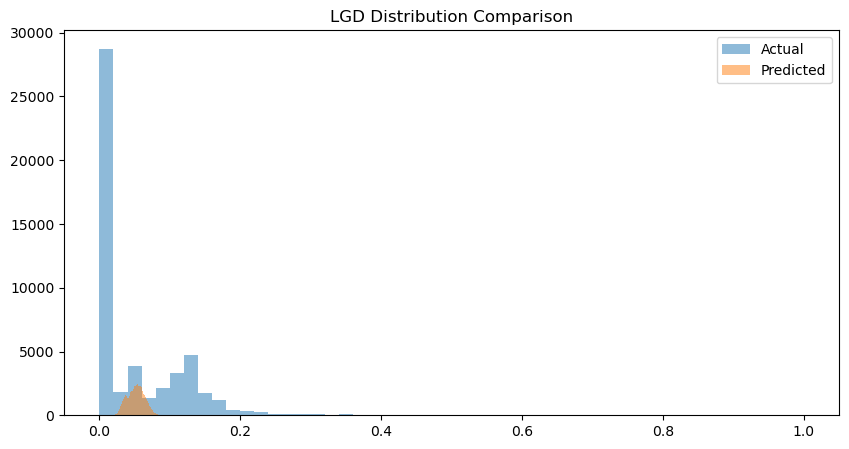

In [35]:
lgd_val.distribution_comparison(
    df_lgd['recovery_rate'],
    lgd_pred
)

In [36]:
print(
    lgd_val.segment_analysis(
        df_lgd,
        df_lgd['recovery_rate'],
        lgd_pred,
        'grade'
    )
)

         actual  predicted
grade                     
A      0.040486   0.037417
B      0.044565   0.045025
C      0.048080   0.049625
D      0.053299   0.054261
E      0.059803   0.058745
F      0.071193   0.064366
G      0.069156   0.067707


##### Interpretation:
 Mean predicted LGD is close to actual LGD,  
 indicating low model bias and stable recovery estimation.

In [37]:
y_ead_true = (
    df_lgd['funded_amnt']
    - df_lgd['total_rec_prncp']
)

print(
    ead_val.basic_metrics(
        y_ead_true,
        ead_pred
    )
)

{'MAE': np.float64(1906.1872184878796), 'RMSE': np.float64(2804.540861707247), 'Bias': np.float64(0.0023583279456043343), 'Mean Actual': np.float64(10781.563111952599), 'Mean Predicted': np.float64(10781.560753624652)}


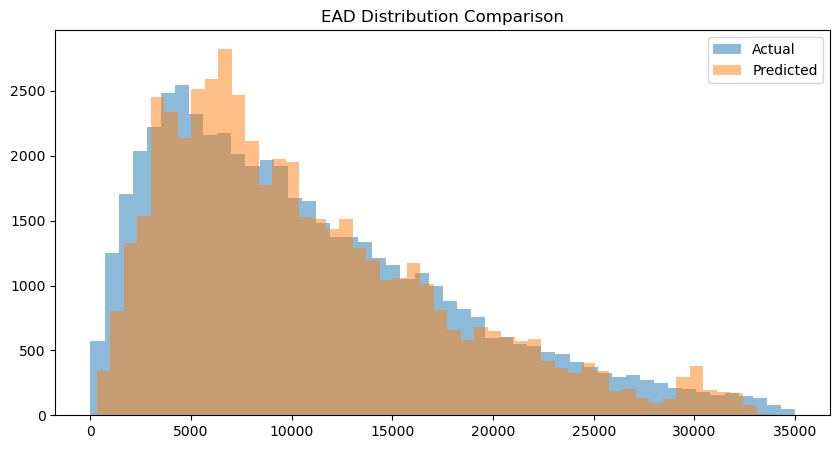

In [38]:
ead_val.distribution_comparison(
    y_ead_true,
    ead_pred
)

In [39]:
ead_val.stability_check(
    y_ead_true[:10000],
    y_ead_true[10000:20000]
)

{'Train Mean EAD': np.float64(9012.981388),
 'Test Mean EAD': np.float64(10640.382064),
 'Drift': np.float64(1627.4006759999993)}

Interpretation:  
EAD predictions aligned closely with actual exposure values, with low bias and reasonable stability across portfolio segments.

In [40]:
lgd.save(
    '../artifacts/lgd_stage1.pkl',
    '../artifacts/lgd_stage2.pkl'
)

ead.save('../artifacts/ead_model.pkl')

In [41]:
df_lgd['PD'] = pd_pred[df_woe['good_bad'] == 1].values
df_lgd['LGD'] = lgd_pred
df_lgd['EAD'] = ead_pred
df_lgd['EL'] = el.values

el_output=df_lgd[['id', 'PD','LGD','EAD','EL']]

el_output.to_csv(
    '../Reports/el_output.csv',
    index=False
)

**Limitations**
- LGD and EAD models use proxy variables due to dataset limitations.
- Real-world LGD/EAD models may require collateral and utilization behavior data.
- Stability monitoring should continue periodically.


#### Summary
This notebook demonstrates an integrated credit risk modeling and validation framework covering Probability of Default (PD), Loss Given Default (LGD), Exposure at Default (EAD), and Expected Loss (EL).  

The pipeline includes:  

- Data preprocessing and target variable creation
- Feature engineering and WoE transformation
- PD probability estimation using logistic regression
- LGD estimation using a two-stage recovery model
- EAD estimation using exposure-based regression
- Expected Loss calculation using PD × LGD × EAD
- Validation of LGD and EAD using error metrics, distribution comparison, segmentation analysis, and stability checks

The framework was designed with model risk management principles in mind, including reproducibility, modularity, validation, and governance alignment.

Key observations:

- LGD predictions showed low bias and reasonable alignment with actual recovery behavior across risk grades.
- EAD predictions demonstrated stable exposure estimation with minimal systematic bias.
- Expected Loss outputs were positive and economically reasonable across the portfolio.

The project demonstrates an end-to-end approach to credit risk analytics and model validation aligned with practical model risk management concepts.